In [ ]:
import pandas as pd

avax_preds = pd.read_csv('Coin_Models/avax_orders.csv')
near_preds = pd.read_csv('Coin_Models/near_orders.csv')
sol_preds = pd.read_csv('Coin_Models/sol_orders.csv')
dot_preds = pd.read_csv('Coin_Models/dot_orders.csv')
near_preds = pd.read_csv('Coin_Models/near_orders.csv')

In [ ]:
avax_preds.drop(columns='Unnamed: 0', inplace=True) 

In [ ]:
'''import numpy as np

class DynamicPortfolio:
    def __init__(self, total_account, initial_funding_fraction=0.5):
        """
        total_account: total available capital (e.g., 1,000,000)
        initial_funding_fraction: fraction of total capital initially available for buys.
        """
        self.total_account = total_account
        # Funding cash is used exclusively to fund buy orders.
        self.funding_cash = total_account * initial_funding_fraction  
        # Liquidation cash comes from sell orders; not used to fund buys.
        self.liquidation_cash = total_account - self.funding_cash  
        self.positions = {}  # Tracks dollar positions in each asset.

    def update_portfolio(self, signals, allocation_factor=0.1, threshold=0.6):
        """
        Update portfolio positions based on signals.
        
        signals: dict mapping asset symbol to (buy_prob, sell_prob)
        allocation_factor: scales the dollar amount per unit probability (as a fraction of total_account)
        threshold: minimum probability required to trigger a buy or sell
        """
        for asset, (buy_prob, sell_prob) in signals.items():
            current_position = self.positions.get(asset, 0)
            
            # Process buy signals:
            if buy_prob > threshold:
                # Compute desired increase: higher buy probability implies a larger allocation.
                desired_increase = buy_prob * allocation_factor * self.total_account
                # Use only funding_cash to fund buys.
                if self.funding_cash >= desired_increase:
                    self.positions[asset] = current_position + desired_increase
                    self.funding_cash -= desired_increase
                    print(f"Bought ${desired_increase:,.2f} of asset {asset}.")
                else:
                    # If not enough funding cash, invest whatever is available.
                    self.positions[asset] = current_position + self.funding_cash
                    print(f"Bought ${self.funding_cash:,.2f} of asset {asset} (all available funding cash).")
                    self.funding_cash = 0

            # Process sell signals:
            elif sell_prob > threshold and current_position > 0:
                # Compute desired reduction.
                desired_reduction = sell_prob * allocation_factor * self.total_account
                reduction = min(desired_reduction, current_position)
                self.positions[asset] = current_position - reduction
                # Proceeds from sales go to the liquidation cash pool.
                self.liquidation_cash += reduction
                print(f"Sold ${reduction:,.2f} of asset {asset}.")
            else:
                print(f"Held asset {asset}.")
    
    def portfolio_status(self):
        """Return a summary of positions and cash balances."""
        total_invested = sum(self.positions.values())
        total_value = total_invested + self.funding_cash + self.liquidation_cash
        return {
            "positions": self.positions,
            "funding_cash": self.funding_cash,
            "liquidation_cash": self.liquidation_cash,
            "total_invested": total_invested,
            "total_account_value": total_value
        }'''

In [ ]:
'''# Simulate 10 time steps with predefined probability signals.
if __name__ == '__main__':
    assets = ['A', 'B', 'C', 'D', 'E']
    portfolio = DynamicPortfolio(total_account=1_000_000, initial_funding_fraction=0.05)
    
    # Define signals for 10 time steps.
    # Each dictionary contains signals for each asset in the form (buy_prob, sell_prob)
    time_steps_signals = [
        {'A': (0.7, 0.1), 'B': (0.3, 0.6), 'C': (0.5, 0.2), 'D': (0.8, 0.3), 'E': (0.2, 0.4)},
        {'A': (0.4, 0.2), 'B': (0.7, 0.2), 'C': (0.6, 0.1), 'D': (0.3, 0.8), 'E': (0.5, 0.2)},
        {'A': (0.8, 0.1), 'B': (0.2, 0.7), 'C': (0.4, 0.2), 'D': (0.9, 0.1), 'E': (0.3, 0.5)},
        {'A': (0.2, 0.8), 'B': (0.6, 0.3), 'C': (0.7, 0.2), 'D': (0.4, 0.6), 'E': (0.5, 0.1)},
        {'A': (0.9, 0.1), 'B': (0.3, 0.7), 'C': (0.2, 0.8), 'D': (0.8, 0.2), 'E': (0.4, 0.6)},
        {'A': (0.3, 0.7), 'B': (0.8, 0.1), 'C': (0.6, 0.2), 'D': (0.2, 0.9), 'E': (0.7, 0.1)},
        {'A': (0.5, 0.2), 'B': (0.4, 0.3), 'C': (0.8, 0.1), 'D': (0.6, 0.2), 'E': (0.3, 0.7)},
        {'A': (0.2, 0.8), 'B': (0.9, 0.1), 'C': (0.4, 0.6), 'D': (0.3, 0.7), 'E': (0.6, 0.2)},
        {'A': (0.7, 0.1), 'B': (0.3, 0.8), 'C': (0.5, 0.2), 'D': (0.4, 0.6), 'E': (0.8, 0.1)},
        {'A': (0.3, 0.7), 'B': (0.5, 0.2), 'C': (0.6, 0.2), 'D': (0.7, 0.1), 'E': (0.4, 0.6)},
    ]
    
    # Loop over each time step, update the portfolio, and display the status.
    for t, signals in enumerate(time_steps_signals, start=1):
        print(f"\nTime Step {t}:")
        portfolio.update_portfolio(signals)
        status = portfolio.portfolio_status()
        print("Portfolio status after this time step:")
        for key, value in status.items():
            print(f"  {key}: {value}")
'''


Time Step 1:
Bought $50,000.00 of asset A (all available funding cash).
Held asset B.
Held asset C.
Bought $0.00 of asset D (all available funding cash).
Held asset E.
Portfolio status after this time step:
  positions: {'A': 50000.0, 'D': 0}
  funding_cash: 0
  liquidation_cash: 950000.0
  total_invested: 50000.0
  total_account_value: 1000000.0

Time Step 2:
Held asset A.
Bought $0.00 of asset B (all available funding cash).
Held asset C.
Held asset D.
Held asset E.
Portfolio status after this time step:
  positions: {'A': 50000.0, 'D': 0, 'B': 0}
  funding_cash: 0
  liquidation_cash: 950000.0
  total_invested: 50000.0
  total_account_value: 1000000.0

Time Step 3:
Bought $0.00 of asset A (all available funding cash).
Held asset B.
Held asset C.
Bought $0.00 of asset D (all available funding cash).
Held asset E.
Portfolio status after this time step:
  positions: {'A': 50000.0, 'D': 0, 'B': 0}
  funding_cash: 0
  liquidation_cash: 950000.0
  total_invested: 50000.0
  total_account_v

In [ ]:
import numpy as np
import pandas as pd

# Example: Softmax probabilities from your model (rows: time, columns: tokens)
y_prob = np.random.rand(100, 5)  # Fake predictions for 5 tokens over 100 time steps
y_prob = y_prob / y_prob.sum(axis=1, keepdims=True)  # Normalize like softmax

# Define a confidence threshold
threshold = 0.6

# Convert probabilities into portfolio weights
weights = np.where(y_prob > threshold, y_prob, 0)  # Zero out weak signals
weights = weights / weights.sum(axis=1, keepdims=True)  # Normalize to 100% allocation

# Convert to DataFrame for easier handling
portfolio_weights = pd.DataFrame(weights, columns=['Token_A', 'Token_B', 'Token_C', 'Token_D', 'Token_E'])
print(portfolio_weights.head())

In [ ]:
initial_capital = 100000  # $100K starting balance
capital_over_time = initial_capital * portfolio_weights  # Allocate capital based on weights

In [ ]:
positions = portfolio_weights.shift(1)  # Use previous day’s weights to avoid lookahead bias
returns = np.random.randn(100, 5) * 0.02  # Fake returns for 5 tokens
portfolio_returns = (positions * returns).sum(axis=1)  # Portfolio P&L
cumulative_returns = (1 + portfolio_returns).cumprod()  # Equity curve

In [ ]:
vol = returns.std(axis=0)
weights_vol_scaled = weights / vol  # Scale inversely with volatility
weights_vol_scaled = weights_vol_scaled / weights_vol_scaled.sum(axis=1, keepdims=True)  # Normalize

In [ ]:
import matplotlib.pyplot as plt

plt.plot(cumulative_returns, label="Strategy")
plt.axhline(1, color='gray', linestyle='--', alpha=0.7)
plt.legend()
plt.title("Portfolio Performance")
plt.show()

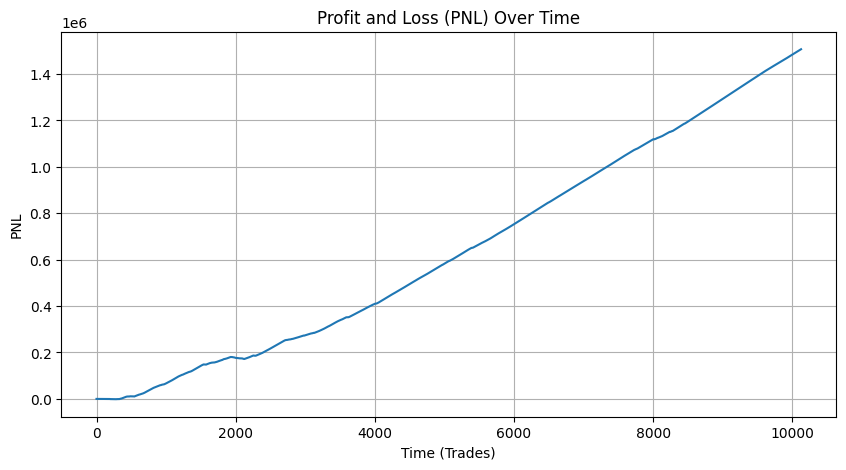

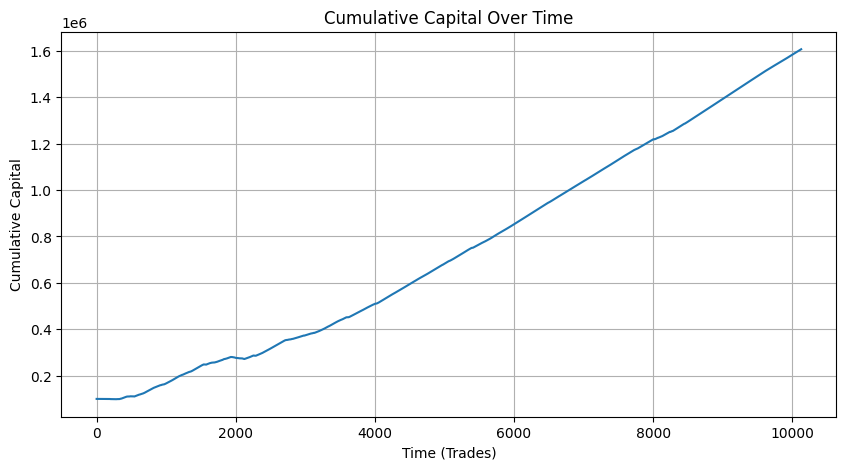

       Probability Hold  Probability Buy  Probability Sell  Prediction  \
0              0.632501         0.078705          0.288795           0   
1              0.615341         0.065981          0.318678           0   
2              0.615780         0.070163          0.314057           0   
3              0.586630         0.052644          0.360726           0   
4              0.565094         0.056092          0.378814           0   
...                 ...              ...               ...         ...   
10123          0.004352         0.974174          0.021474           1   
10124          0.004274         0.975230          0.020496           1   
10125          0.003226         0.979110          0.017664           1   
10126          0.004472         0.970089          0.025439           1   
10127          0.003293         0.982219          0.014489           1   

       Investment  Cumulative_Investment           PNL  Cumulative_Capital  
0        0.000000           0.0000

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

def calculate_investment_portfolio(df, starting_capital, portfolio_size):
    """
    Calculates investment amounts for each coin based on predicted classifications and probabilities.

    Args:
        df (pd.DataFrame): DataFrame with prediction probabilities and classifications.
        starting_capital (float): Total starting capital.
        portfolio_size (int): Number of coins in the portfolio.

    Returns:
        pd.DataFrame: DataFrame with an added "Investment" column.
    """

    max_investment_per_coin = starting_capital / portfolio_size

    def calculate_investment(row):
        if row["Prediction"] == 1:
            return max_investment_per_coin * row["Probability Buy"] / 100
        elif row["Prediction"] == 2:
            return -max_investment_per_coin * row["Probability Sell"] / 100
        else:
            return 0

    df["Investment"] = df.apply(calculate_investment, axis=1)
    return df

def calculate_pnl(df, initial_capital):
  """
  Calculates the cumulative profit and loss (PNL) over time.

  Args:
      df (pd.DataFrame): DataFrame with "Investment" column.
      initial_capital (float): Starting capital.

  Returns:
      pd.Series: Cumulative PNL values.
  """
  df['Cumulative_Investment'] = df['Investment'].cumsum()
  df['PNL'] = df['Cumulative_Investment']
  df['Cumulative_Capital'] = initial_capital + df['PNL']
  return df['PNL'], df['Cumulative_Capital']

# Define starting capital and portfolio size
starting_capital = 100000
portfolio_size = 5

# Calculate investment amounts
df_with_investment = calculate_investment_portfolio(avax_preds.copy(), starting_capital, portfolio_size)

# Calculate PNL
pnl, cumulative_capital = calculate_pnl(df_with_investment, starting_capital)

# Plot PNL
plt.figure(figsize=(10, 5))
plt.plot(pnl)
plt.title("Profit and Loss (PNL) Over Time")
plt.xlabel("Time (Trades)")
plt.ylabel("PNL")
plt.grid(True)
plt.show()

#Plot cumulative capital
plt.figure(figsize=(10, 5))
plt.plot(cumulative_capital)
plt.title("Cumulative Capital Over Time")
plt.xlabel("Time (Trades)")
plt.ylabel("Cumulative Capital")
plt.grid(True)
plt.show()

print(df_with_investment)

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

def calculate_investment_portfolio(df, starting_capital, portfolio_size, coin_names):
    """
    Calculates investment amounts for each coin based on predicted classifications and probabilities,
    with capital constraints.
    """

    max_investment_per_coin = starting_capital / portfolio_size
    coin_investments = {coin: 0 for coin in coin_names}  # Track investment per coin using coin names

    def calculate_investment(row, coin_name):
        prediction = row["Prediction"]
        prob_buy = row["Probability Buy"] / 100
        prob_sell = row["Probability Sell"] / 100

        if prediction == 1:  # Buy
            if coin_investments[coin_name] < max_investment_per_coin:
                investment_amount = min(max_investment_per_coin - coin_investments[coin_name], max_investment_per_coin * prob_buy)
                coin_investments[coin_name] += investment_amount
                return investment_amount
            else:
                return 0  # Hold due to max investment reached
        elif prediction == 2:  # Sell
            investment_amount = -min(coin_investments[coin_name], max_investment_per_coin * prob_sell)
            coin_investments[coin_name] += investment_amount
            return investment_amount
        else:  # Hold
            return 0

    df["Investment"] = df.apply(lambda row: calculate_investment(row, df.index[row.name]), axis=1) # use coin names from index
    return df

def calculate_pnl(df, initial_capital):
    """Calculates PNL and cumulative capital."""
    df['Cumulative_Investment'] = df['Investment'].cumsum()
    df['PNL'] = df['Cumulative_Investment']
    df['Cumulative_Capital'] = initial_capital + df['PNL']
    return df['PNL'], df['Cumulative_Capital']

# Example DataFrame (replace with your actual avax_preds)
data = {
    "Probability Hold": [20, 60, 10, 30, 80, 50, 30, 20, 90, 10],
    "Probability Buy": [50, 20, 70, 40, 10, 20, 60, 80, 5, 70],
    "Probability Sell": [30, 20, 20, 30, 10, 30, 10, 0, 5, 20],
    "Prediction": [1, 0, 1, 0, 0, 2, 1, 1, 0, 1]
}
coin_names = ['BTC', 'ETH', 'LTC', 'XRP', 'ADA', 'DOGE', 'SOL', 'AVAX', 'DOT', 'MATIC'] # Example coin names
avax_preds = pd.DataFrame(data, index = coin_names) #set index to coin names

starting_capital = 100000
portfolio_size = 5

df_with_investment = calculate_investment_portfolio(avax_preds.copy(), starting_capital, portfolio_size, coin_names)

pnl, cumulative_capital = calculate_pnl(df_with_investment, starting_capital)

plt.figure(figsize=(10, 5))
plt.plot(pnl)
plt.title("Profit and Loss (PNL) Over Time")
plt.xlabel("Time (Trades)")
plt.ylabel("PNL")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(cumulative_capital)
plt.title("Cumulative Capital Over Time")
plt.xlabel("Time (Trades)")
plt.ylabel("Cumulative Capital")
plt.grid(True)
plt.show()

print(df_with_investment)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices